<a href="https://colab.research.google.com/github/tarshibofficial/Ai-ML/blob/main/210104_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load from GitHub


In [92]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/tarshibofficial/Ai-ML/main/dataset/diabetes.csv"

df = pd.read_csv(url)


#Dataset Explore

In [93]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [94]:
df.shape

(768, 9)

In [95]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [96]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [97]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [98]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#Feature Selection

In [99]:
x = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'DiabetesPedigreeFunction', 'Age']]

y = df[['BMI']]

In [100]:
x.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [101]:
y.columns

Index(['BMI'], dtype='object')

#Train Test Split

In [102]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=33)

In [103]:
x_train.shape

(614, 7)

In [104]:
x_test.shape

(154, 7)

#Normalization

In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#Train Linear Regression Model

In [106]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [107]:
model.fit(x_train_scaled, y_train)

LinearRegression()

In [108]:
train_score = model.score(x_train_scaled, y_train)

print("Training R² Score:", train_score)

Training R² Score: 0.2590123705257328


#Sample Prediction Table

In [109]:
y_pred = model.predict(x_test_scaled)


In [110]:
results = pd.DataFrame({
    'Predicted BMI': y_pred.flatten(),
    'Actual BMI': y_test.to_numpy().flatten(),
    'Difference': abs(y_pred.flatten() - y_test.to_numpy().flatten()),
    'Percentage Error (%)': abs(y_pred.flatten() - y_test.to_numpy().flatten()) / y_test.to_numpy().flatten() * 100
})

results.head(20)

/tmp/ipykernel_2233/861004010.py:5: RuntimeWarning: divide by zero encountered in divide
  'Percentage Error (%)': abs(y_pred.flatten() - y_test.to_numpy().flatten()) / y_test.to_numpy().flatten() * 100


,Predicted BMI,Actual BMI,Difference,Percentage Error (%)
0,27.583481,26.7,0.883481,3.308916
1,29.827162,0.0,29.827162,inf
2,32.115822,29.7,2.415822,8.134081
3,28.819293,24.5,4.319293,17.629766
4,37.282457,31.6,5.682457,17.982460
5,28.321441,30.5,2.178559,7.142818
6,35.377219,40.6,5.222781,12.863993
7,39.107537,32.7,6.407537,19.594913
8,31.740010,25.0,6.740010,26.960039
9,27.477929,30.1,2.622071,8.711201


#Evaluation Metrics

In [111]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)

Mean Absolute Error (MAE): 4.942081202330723
Mean Squared Error (MSE): 44.22477878116476
Root Mean Squared Error (RMSE): 6.650171334722494
R-squared (R²): 0.04790342367462208


#Predicted vs Actual Graph

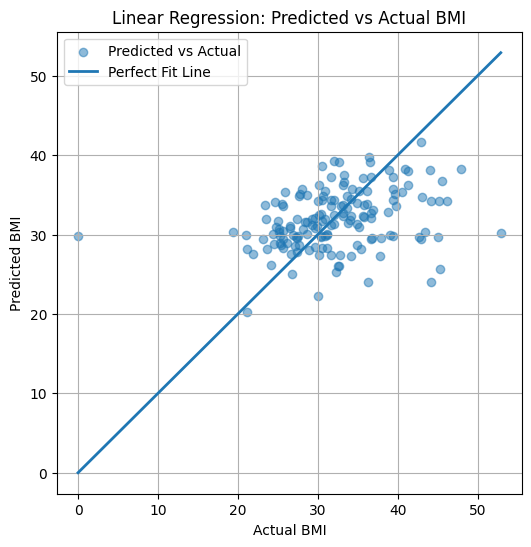

In [112]:
import matplotlib.pyplot as plt



plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5, label='Predicted vs Actual')

min_value = min(y_test.to_numpy().min(), y_pred.min())
max_value = max(y_test.to_numpy().max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linewidth=2,
    label='Perfect Fit Line'
)

plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Linear Regression: Predicted vs Actual BMI")
plt.legend()
plt.grid(True)
plt.show()

#Loss Curve

In [113]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

y_train_1d = y_train.values.ravel()
y_test_1d = y_test.values.ravel()


sgd_model = SGDRegressor(
    max_iter=1,
    tol=None,
    learning_rate='invscaling',
    eta0=0.01,
    random_state=42
)


train_losses = []
val_losses = []

epochs = 50

for epoch in range(epochs):
    sgd_model.partial_fit(x_train_scaled, y_train_1d)

    y_train_pred = sgd_model.predict(x_train_scaled)
    train_loss = mean_squared_error(y_train_1d, y_train_pred)

    y_val_pred = sgd_model.predict(x_test_scaled)
    val_loss = mean_squared_error(y_test_1d, y_val_pred)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

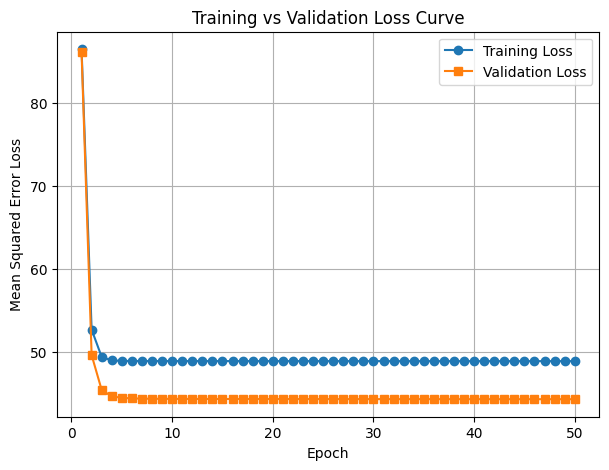

In [114]:
plt.figure(figsize=(7,5))

plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', marker='s')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Training vs Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

#R² Curve

In [115]:
model_r2 = SGDRegressor(
    max_iter=1,
    tol=None,
    learning_rate='invscaling',
    eta0=0.01,
    random_state=42
)


train_r2_scores = []
val_r2_scores = []

epochs = 50

for epoch in range(epochs):
    model_r2.partial_fit(x_train_scaled, y_train_1d)

    y_train_pred = model_r2.predict(x_train_scaled)
    y_val_pred = model_r2.predict(x_test_scaled)

    train_r2 = r2_score(y_train_1d, y_train_pred)
    val_r2 = r2_score(y_test_1d, y_val_pred)

    train_r2_scores.append(train_r2)
    val_r2_scores.append(val_r2)

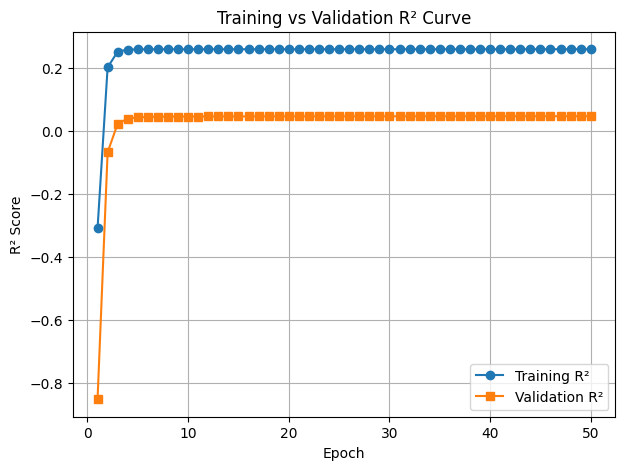

In [116]:
plt.figure(figsize=(7,5))

plt.plot(range(1, epochs + 1), train_r2_scores, label='Training R²', marker='o')
plt.plot(range(1, epochs + 1), val_r2_scores, label='Validation R²', marker='s')

plt.xlabel('Epoch')
plt.ylabel('R² Score')
plt.title('Training vs Validation R² Curve')
plt.legend()
plt.grid(True)
plt.show()